/var/folders/dh/dmftg40j21j249nqf2z5v2nh0000gn/T/ipykernel_8115/1331747678.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(x='Value',


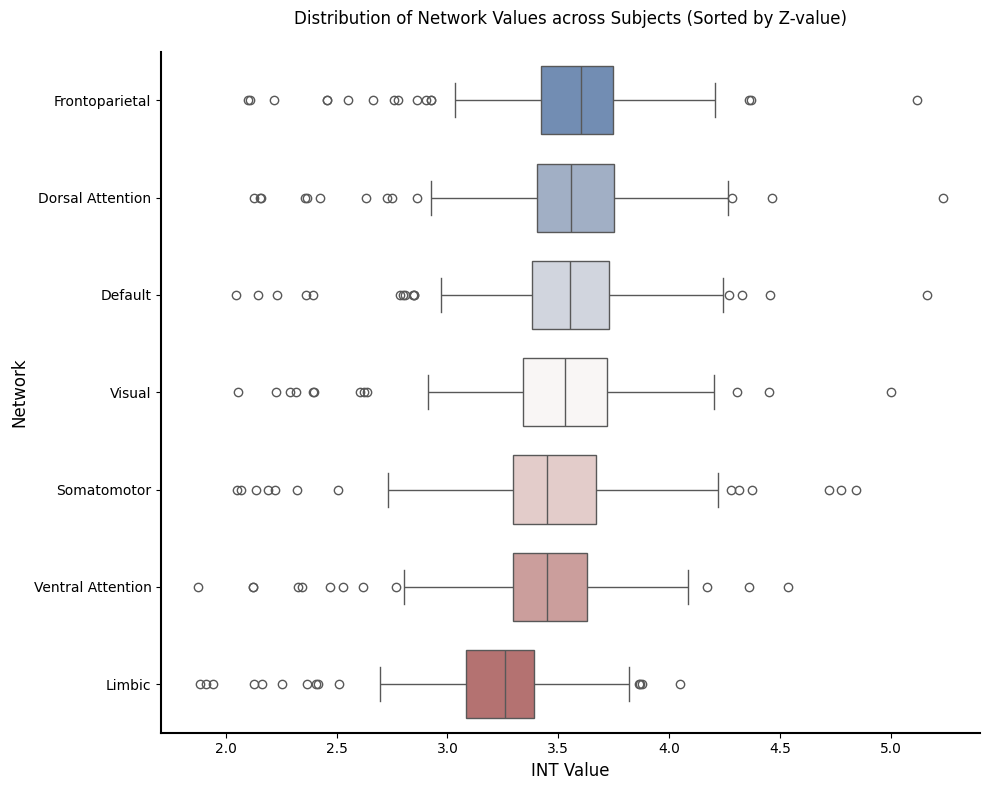

In [13]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
dpath = '/Volumes/QC/INT/INT_BN246_HC135BP_BP135MDD/volume/INTvalue_HCgroup_net7.csv'
# 从 CSV 文件中读取数据
df = pd.read_csv(dpath)

# # 将数据转换为长格式
df_long = df.melt(id_vars=['subID', '0'],
                 value_vars=['Visual', 'Somatomotor', 'Dorsal Attention',
                            'Ventral Attention', 'Limbic', 'Frontoparietal', 'Default'],
                 var_name='Network',
                 value_name='Value')

# # 将数据转换为长格式
# df_long = df.melt(id_vars=['subID'],
#                   value_vars=['DorsAttn', 'Cont', 'SalVentAttn', 'SomMot', 'Default', 'Limbic', 'Vis'],
#                   var_name='Network',
#                   value_name='Value')


# 计算每个网络的z轴值（这里假设是均值，可根据实际需求修改）
network_z_values = df_long.groupby('Network')['Value'].mean().sort_values(ascending=False)

# 获取排序后的网络顺序
network_order = network_z_values.index.tolist()

plt.figure(figsize=(10, 8))

# 绘制横向箱体图，使用排序后的网络顺序
ax = sns.boxplot(x='Value',
            y='Network',
            data=df_long,
            order=network_order,
            orient='h',
            palette='vlag',
            width=0.7)

# 设置背景颜色为透明
ax.set_facecolor('none')

# 关闭网格线显示
ax.grid(False)

# 确保坐标轴可见
ax.spines['bottom'].set_visible(True)
ax.spines['left'].set_visible(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# 设置坐标轴颜色和线宽
ax.spines['bottom'].set_color('black')
ax.spines['left'].set_color('black')
ax.spines['bottom'].set_linewidth(1.5)
ax.spines['left'].set_linewidth(1.5)

# 添加标题和标签
plt.title('Distribution of Network Values across Subjects (Sorted by Z-value)', pad=20)
plt.xlabel('INT Value', fontsize=12)
plt.ylabel('Network', fontsize=12)
plt.savefig('/Volumes/QC/INT/INT_BN246_HC135BP_BP135MDD/volume/7net.png', dpi=300)
# 调整布局
plt.tight_layout()
plt.show()


/var/folders/dh/dmftg40j21j249nqf2z5v2nh0000gn/T/ipykernel_8115/1643807640.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(x='Value',


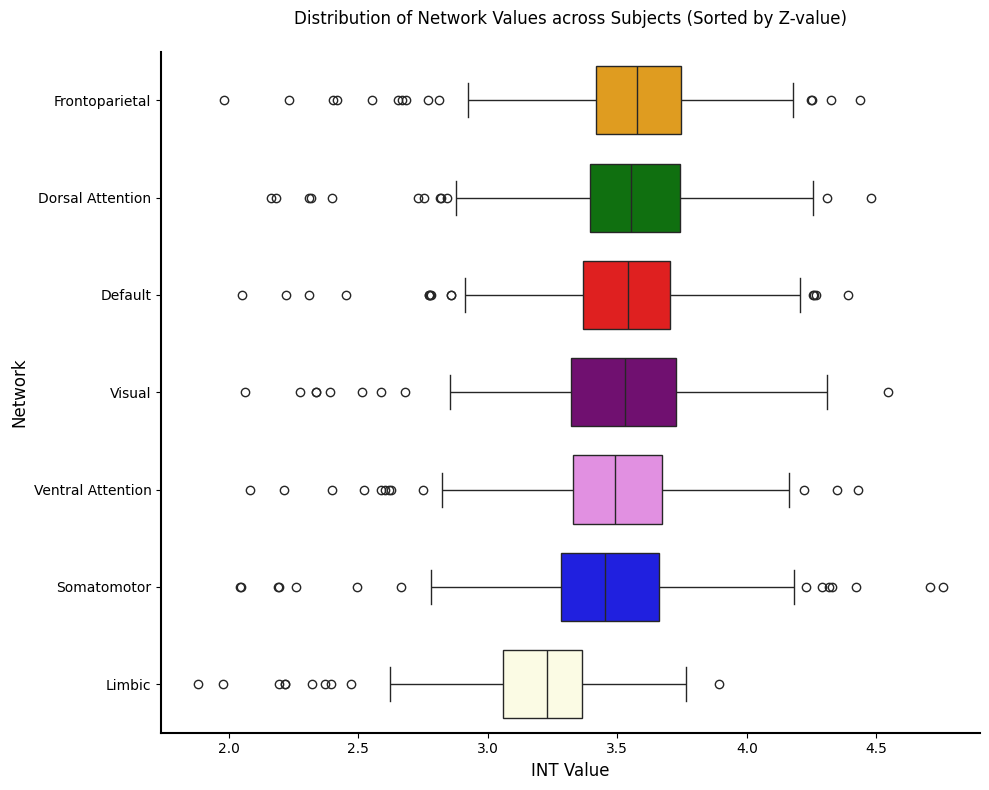

In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 从 CSV 文件中读取数据
df = pd.read_csv('/Volumes/QC/INT/INT_BN246_HC135BP_BP135MDD/Results/INTvalue_HCgroup_net7.csv')

# 将数据转换为长格式
df_long = df.melt(id_vars=['subID', '0'],
                 value_vars=['Visual', 'Somatomotor', 'Dorsal Attention',
                            'Ventral Attention', 'Limbic', 'Frontoparietal', 'Default'],
                 var_name='Network',
                 value_name='Value')

# 计算每个网络的z轴值（这里假设是均值，可根据实际需求修改）
network_z_values = df_long.groupby('Network')['Value'].mean().sort_values(ascending=False)

# 获取排序后的网络顺序
network_order = network_z_values.index.tolist()

# 创建自定义颜色映射
custom_palette = {
    'Visual': 'purple',
    'Somatomotor': 'blue',
    'Dorsal Attention': 'green',
    'Ventral Attention': 'violet',
    'Limbic': 'lightyellow',
    'Frontoparietal': 'orange',
    'Default': 'red'
}

plt.figure(figsize=(10, 8))

# 绘制横向箱体图，使用排序后的网络顺序和自定义颜色
ax = sns.boxplot(x='Value',
            y='Network',
            data=df_long,
            order=network_order,
            orient='h',
            palette=custom_palette,
            width=0.7)

# 设置背景颜色为透明
ax.set_facecolor('none')

# 关闭网格线显示
ax.grid(False)

# 确保坐标轴可见
ax.spines['bottom'].set_visible(True)
ax.spines['left'].set_visible(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# 设置坐标轴颜色和线宽
ax.spines['bottom'].set_color('black')
ax.spines['left'].set_color('black')
ax.spines['bottom'].set_linewidth(1.5)
ax.spines['left'].set_linewidth(1.5)

# 添加标题和标签
plt.title('Distribution of Network Values across Subjects (Sorted by Z-value)', pad=20)
plt.xlabel('INT Value', fontsize=12)
plt.ylabel('Network', fontsize=12)
plt.savefig('/Volumes/QC/INT/INT_BN246_HC135BP_BP135MDD/Results/7net.png', dpi=300)

# 调整布局
plt.tight_layout()
plt.show()


提取数据

In [6]:
import glob
import os
from shutil import copy
path = '/Volumes/QCII/Data135_processed/xcpd_out_mdd/xcp_d/sub-MDD*/func/*_task-rest_acq-ap_run-1_space-fsLR_atlas-4S456Parcels_den-91k_measure-pearsoncorrelation_conmat.pconn.nii'

data = glob.glob(path)

for i in data:

    subID = i.split('/')[-3]
    finame = i.split('/')[-1]

    newpth = '/Volumes/QC/Data/Schaefer400_FC/MDD_BP135/'+finame

    copy(i, newpth)



合并数据-两表相同

In [1]:
import numpy as np
import pandas as pd
file_1 ='/Volumes/QC/INT/INT_BN246_HC_MDD/INT_Results/INTvalue_MDD.csv'
file_2 ='/Volumes/QC/INT/INT_BN246_HC_MDD/INT_Results/clinicalInformation/MDD_age_sex.csv'

#Read the CSV files into DataFrames
df1 = pd.read_csv(file_1)
df2 = pd.read_csv(file_2)

df_new = pd.merge(df2, df1, on='subID', how='inner')
df_new.to_csv('/Volumes/QC/INT/INT_BN246_HC_MDD/INT_Results/INT_MDD.csv', index=False,encoding='utf-8-sig')
